In [139]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# import nessecory lib.

In [140]:
# loding the dataset 
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
fulfilment = pd.read_csv('fulfilment_center_info.csv')
meal = pd.read_csv('meal_info.csv')

In [141]:
train_merged = train.merge(fulfilment, on = 'center_id', how = 'left')  # merge the dataset train and fulfilment 
train_merged = train_merged.merge(meal, on = 'meal_id', how = 'left')   # merge the dataset train_merged and meal

test_merged = test.merge(fulfilment, on = 'center_id', how = 'left')    # same as training data merge test data
test_merged = test_merged.merge(meal, on = 'meal_id', how = 'left')

In [142]:
train_merged.to_csv('train_merged.csv', index = False)  # save the copy of merged datdasets
test_merged.to_csv('test_merged.csv', index = False)

In [143]:
print(train_merged.isna().sum())
print(f'\nduplicated values : {train_merged.duplicated().sum()}')

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64

duplicated values : 0


In [144]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian


In [145]:
wk = train_merged.groupby("week", as_index=False)["num_orders"].sum()

In [146]:
wk

,week,num_orders
0,1,792261
1,2,787084
2,3,695262
3,4,743529
4,5,1198675
...,...,...
140,141,776240
141,142,739661
142,143,759926
143,144,801197


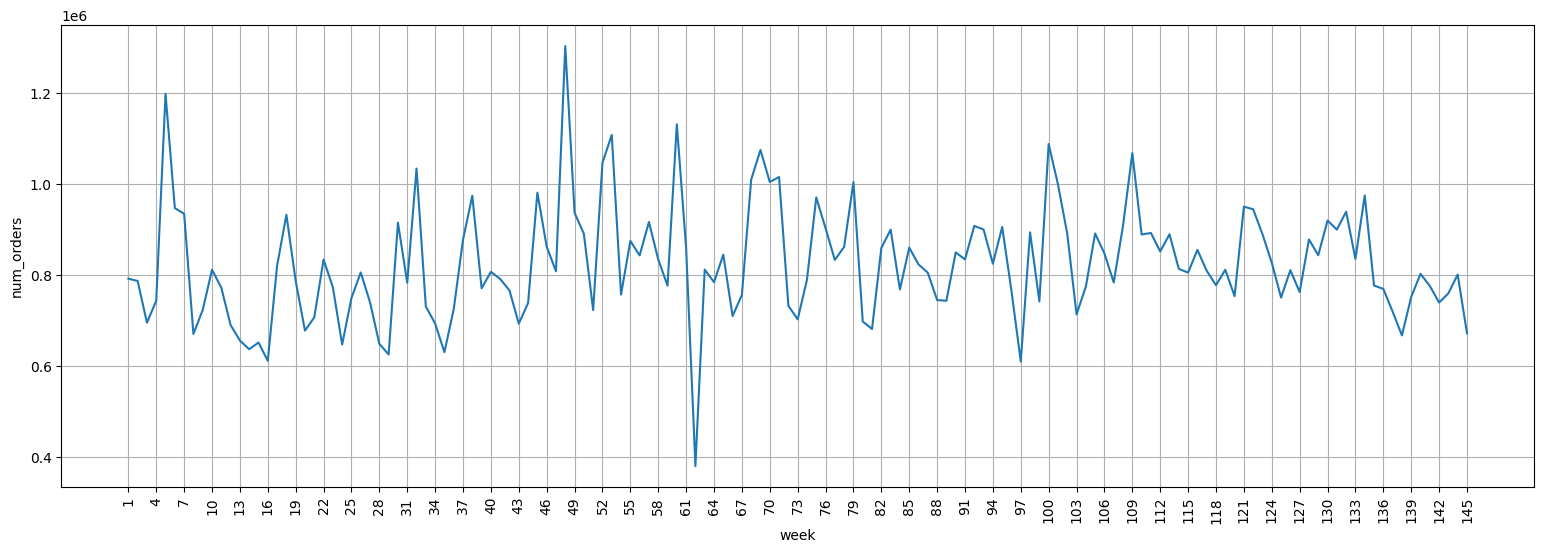

In [147]:
plt.figure(figsize=(19, 6))
sns.lineplot(wk, y = 'num_orders', x = 'week', markers = 'o')
plt.xticks(wk['week'][::3], rotation = 90)
plt.grid()
plt.show()

In [148]:
train_merged['discount'] = train_merged['base_price'] - train_merged['checkout_price']

In [149]:
train_merged['discount'] = train_merged['discount'].round(2)

In [150]:
train_merged.sort_values(by ='discount' ,ascending=False)

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount
108288,1419554,37,102,2444,145.53,707.13,0,0,54,593,77,TYPE_A,2.8,Seafood,Continental,561.60
287522,1176573,94,92,2444,163.93,708.13,1,0,15,526,34,TYPE_C,2.9,Seafood,Continental,544.20
258834,1000988,85,161,2304,226.04,736.23,0,0,69,658,34,TYPE_B,3.9,Desert,Indian,510.19
111288,1192242,38,102,2444,243.50,708.13,0,0,15,593,77,TYPE_A,2.8,Seafood,Continental,464.63
262090,1181537,86,161,2304,338.59,736.23,1,1,134,658,34,TYPE_B,3.9,Desert,Indian,397.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331761,1332869,107,23,1230,497.61,325.01,0,1,42,698,23,TYPE_A,3.4,Beverages,Continental,-172.60
327056,1290542,106,153,2322,496.64,322.10,0,1,41,590,56,TYPE_A,3.9,Beverages,Continental,-174.54
331762,1056437,107,23,2322,503.49,324.01,0,1,13,698,23,TYPE_A,3.4,Beverages,Continental,-179.48
328498,1238282,106,23,2322,508.31,324.01,0,1,121,698,23,TYPE_A,3.4,Beverages,Continental,-184.30


In [151]:
train_merged["discount_per"] = (((train_merged["base_price"] - train_merged["checkout_price"])/ train_merged["base_price"]) * 100).round(2)

In [152]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


In [153]:
train_merged.sort_values(by ='discount_per' ,ascending=False)

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
110286,1300283,38,73,1230,2.97,316.25,0,0,14,576,34,TYPE_A,4.0,Beverages,Continental,313.28,99.06
173526,1017697,58,102,1109,56.26,319.13,0,0,229,593,77,TYPE_A,2.8,Rice Bowl,Indian,262.87,82.37
44875,1381921,16,41,1248,45.62,253.23,0,0,123,590,56,TYPE_C,1.9,Beverages,Indian,207.61,81.98
44874,1414392,16,41,2631,47.59,253.23,0,0,163,590,56,TYPE_C,1.9,Beverages,Indian,205.64,81.21
224346,1472105,74,80,1198,65.02,319.13,0,0,69,604,56,TYPE_C,5.1,Extras,Thai,254.11,79.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328497,1406829,106,23,1230,509.31,324.01,0,1,107,698,23,TYPE_A,3.4,Beverages,Continental,-185.30,-57.19
442314,1267391,141,72,1248,163.93,98.03,0,1,27,638,56,TYPE_C,3.9,Beverages,Indian,-65.90,-67.22
442313,1288740,141,72,2631,163.93,98.03,0,1,69,638,56,TYPE_C,3.9,Beverages,Indian,-65.90,-67.22
445564,1228305,142,72,1248,163.02,97.03,0,1,80,638,56,TYPE_C,3.9,Beverages,Indian,-65.99,-68.01


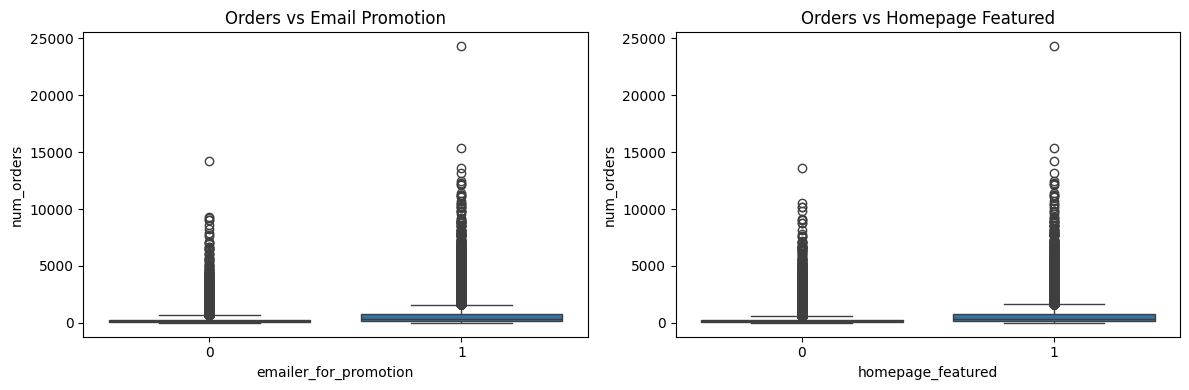

In [154]:

fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.boxplot(data=train_merged, x="emailer_for_promotion", y="num_orders", ax=ax[0])
ax[0].set_title("Orders vs Email Promotion")

sns.boxplot(data=train_merged, x="homepage_featured", y="num_orders", ax=ax[1])
ax[1].set_title("Orders vs Homepage Featured")
plt.tight_layout()
plt.show()




In [155]:
train_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   city_code              456548 non-null  int64  
 10  region_code            456548 non-null  int64  
 11  center_type            456548 non-null  object 
 12  op_area                456548 non-null  float64
 13  category               456548 non-null  object 
 14  cuisine                456548 non-nu

In [156]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


<Axes: >

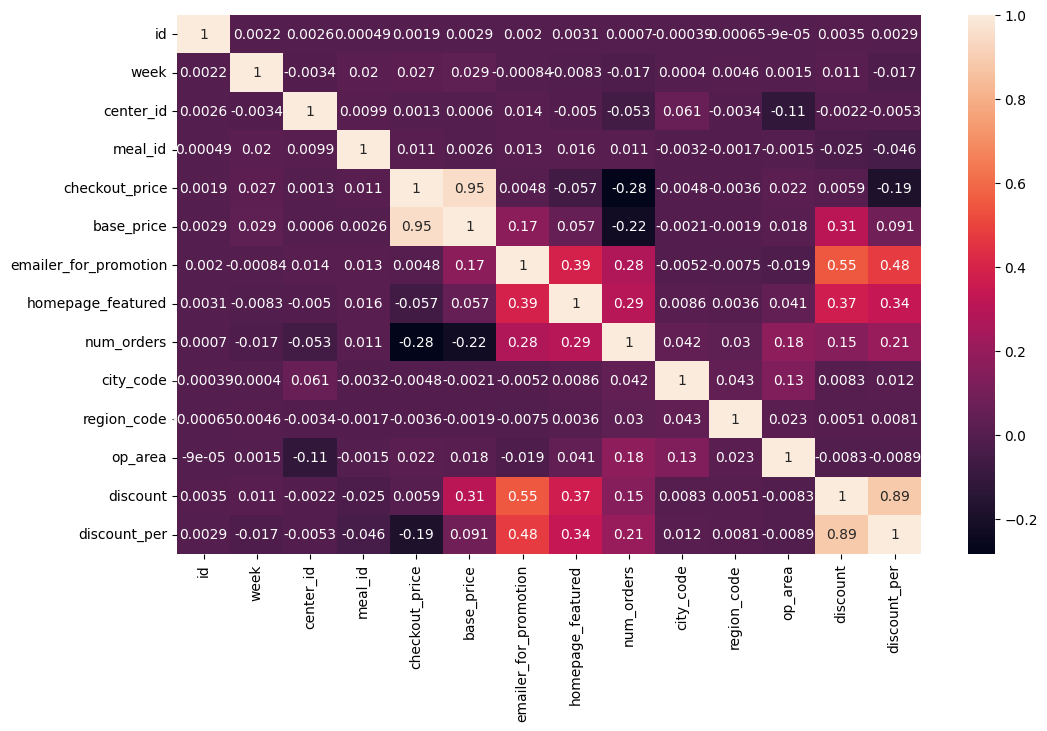

In [157]:
plt.figure(figsize=(12,7))
sns.heatmap(train_merged.corr(numeric_only=True), annot=True)

In [158]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


In [159]:
total_order_center = train_merged.groupby('center_id')['num_orders'].sum()

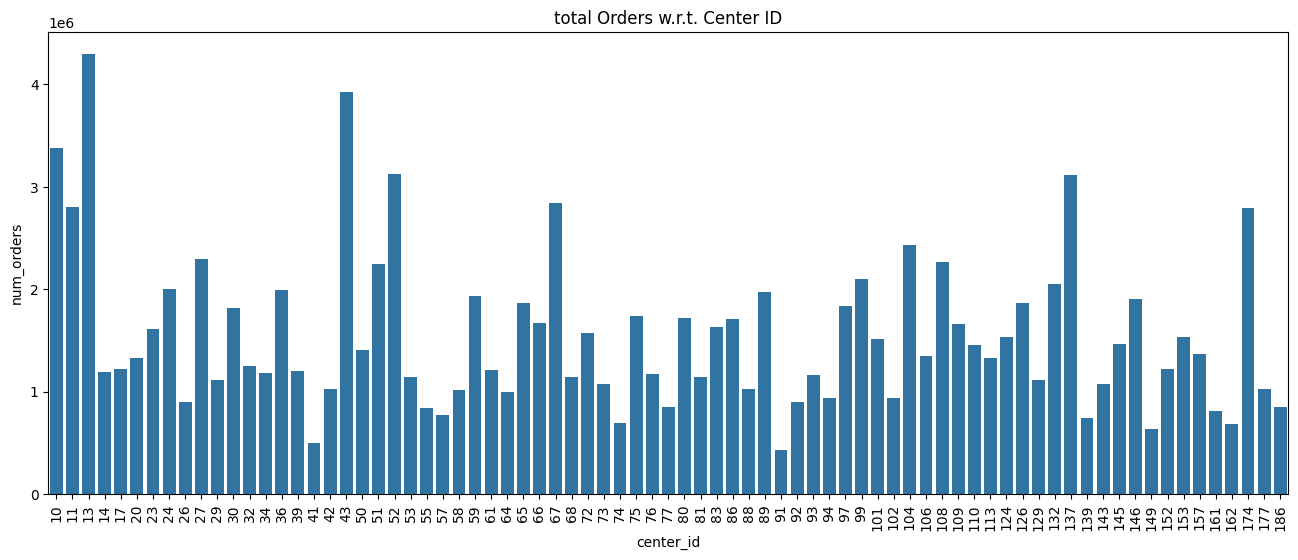

In [160]:
plt.figure(figsize = (16,6))
sns.barplot(total_order_center)
plt.xticks(rotation = 90)
plt.title('total Orders w.r.t. Center ID')
plt.show()

In [161]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


In [162]:
train_merged['center_type'].value_counts()

center_type
TYPE_A    262881
TYPE_C     99593
TYPE_B     94074
Name: count, dtype: int64

<Axes: xlabel='center_type', ylabel='num_orders'>

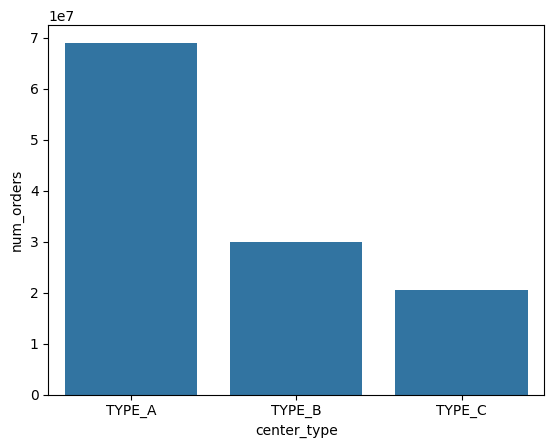

In [163]:
total_order_center_type = train_merged.groupby('center_type')['num_orders'].sum()
sns.barplot(total_order_center_type)

In [164]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


<Axes: xlabel='region_code', ylabel='num_orders'>

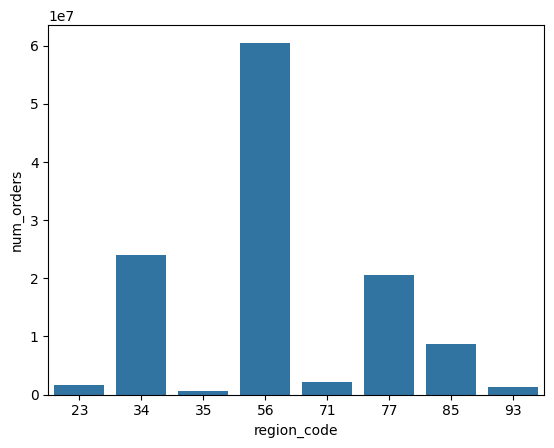

In [165]:
total_order_region = train_merged.groupby('region_code')['num_orders'].sum()

sns.barplot(total_order_region)

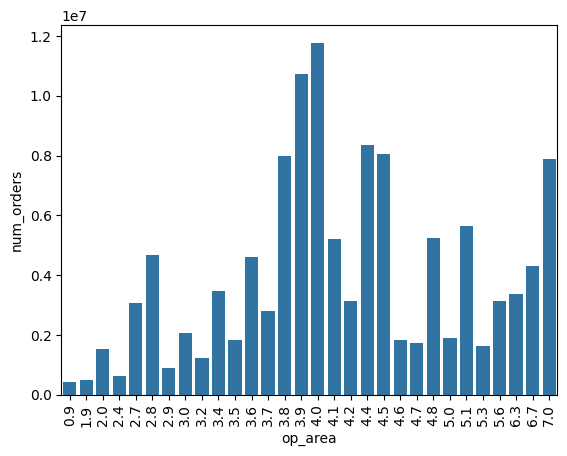

In [166]:
total_order_area = train_merged.groupby('op_area')['num_orders'].sum()

sns.barplot(total_order_area)
plt.xticks(rotation = 90)
plt.show()

In [167]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


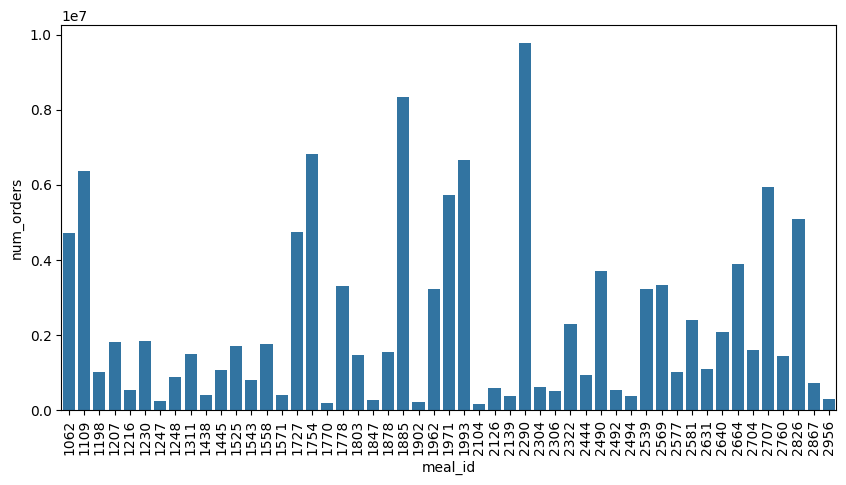

In [168]:
total_order_meal = train_merged.groupby('meal_id')['num_orders'].sum()
plt.figure(figsize=(10,5))
sns.barplot(total_order_meal)
plt.xticks(rotation = 90)
plt.show()

In [169]:
print(train_merged['cuisine'].value_counts())
print(train_merged['category'].value_counts())

cuisine
Italian        122925
Thai           118216
Indian         112612
Continental    102795
Name: count, dtype: int64
category
Beverages       127890
Rice Bowl        33408
Sandwich         33291
Pizza            33138
Starters         29941
Other Snacks     29379
Desert           29294
Salad            28559
Pasta            27694
Seafood          26916
Biryani          20614
Extras           13562
Soup             12675
Fish             10187
Name: count, dtype: int64


In [170]:


meal_week = (
    train_merged.groupby(["meal_id", "week"], as_index=False)["num_orders"]
    .sum()
    .sort_values(["meal_id", "week"])
)

# seasonal strength score per meal (higher = stronger repeating pattern)
seasonality = (
    meal_week.groupby("meal_id")["num_orders"]
    .apply(lambda s: s.autocorr(lag=52) if len(s) > 52 else np.nan)
    .reset_index(name="seasonality_score")
    .sort_values("seasonality_score", ascending=False)
)

seasonality.head(20)   # strongest seasonal meals


,meal_id,seasonality_score
20,1847,0.753204
32,2306,0.600986
37,2494,0.580460
9,1438,0.550967
19,1803,0.471212
36,2492,0.466017
15,1727,0.429894
22,1885,0.405325
26,1993,0.405049
5,1230,0.393160


In [171]:
train_merged.loc[train_merged["discount_per"] < 0, "discount_per"] = 0

In [172]:
disc_bins = [-0.01, 0, 5, 10, 20, 30, 40, 50, 100]
disc_labels = ["0%", "0-5%", "5-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50%+"]

train_merged["discount_bin"] = pd.cut(
    train_merged["discount_per"],
    bins=disc_bins,
    labels=disc_labels,
    include_lowest=True
)

# Demand vs discount bins
disc_summary = (
    train_merged.groupby("discount_bin", observed=False)["num_orders"]
    .agg(total_orders="sum", avg_orders="mean", count="count")
    .reset_index()
)
disc_summary

,discount_bin,total_orders,avg_orders,count
0,0%,49307770,217.346019,226863
1,0-5%,25265319,219.728997,114984
2,5-10%,1732646,372.932845,4646
3,10-20%,18021618,346.256614,52047
4,20-30%,10542801,353.963438,29785
5,30-40%,9625242,443.600424,21698
6,40-50%,4585552,1059.753178,4327
7,50%+,476537,216.804823,2198


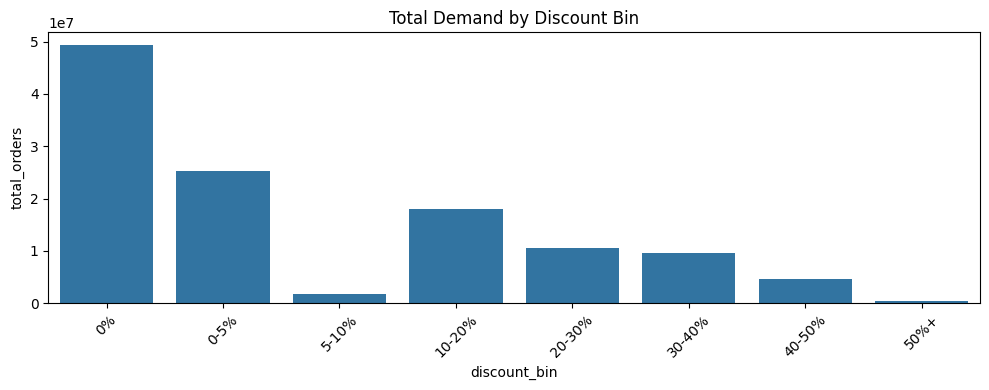

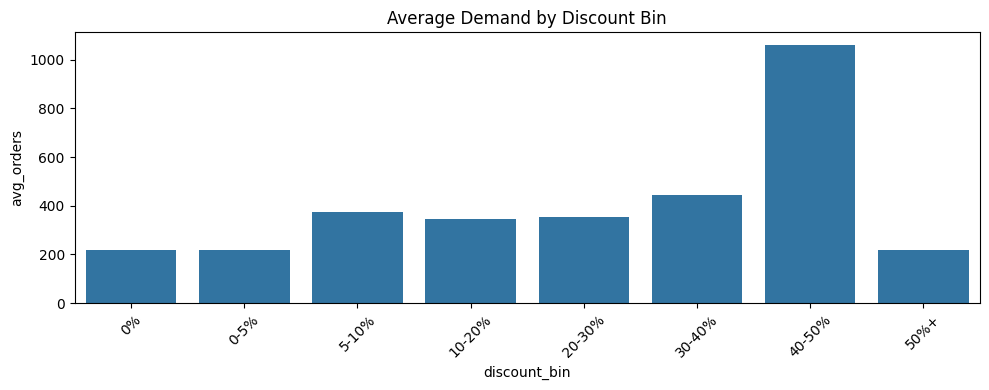

In [173]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.barplot(data=disc_summary, x="discount_bin", y="total_orders")
plt.title("Total Demand by Discount Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(data=disc_summary, x="discount_bin", y="avg_orders")
plt.title("Average Demand by Discount Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [174]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per,discount_bin
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15,10-20%
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,0.00,0%
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74,0-5%
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41,20-30%
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,0.00,0%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97,20-30%
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29,20-30%


In [ ]:
price_bins = [0, 100, 150, 200, 250, 300, 400, 600, np.inf]
price_labels = ["<=100", "101-150", "151-200", "201-250", "251-300", "301-400", "401-600", "600+"]

train_merged["price_band"] = pd.cut(
    train_merged["checkout_price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

price_summary = (
    train_merged.groupby("price_band", observed=False)["num_orders"]
    .agg(total_orders="sum", avg_orders="mean", count="count")
    .reset_index()
)
price_summary


,price_band,total_orders,avg_orders,count
0,<=100,3460572,293.592263,11787
1,101-150,15133121,506.531028,29876
2,151-200,25846781,419.542925,61607
3,201-250,16968062,339.762159,49941
4,251-300,21885341,279.806446,78216
5,301-400,19633391,223.187875,87968
6,401-600,13300279,136.004407,97793
7,600+,3329938,84.602083,39360


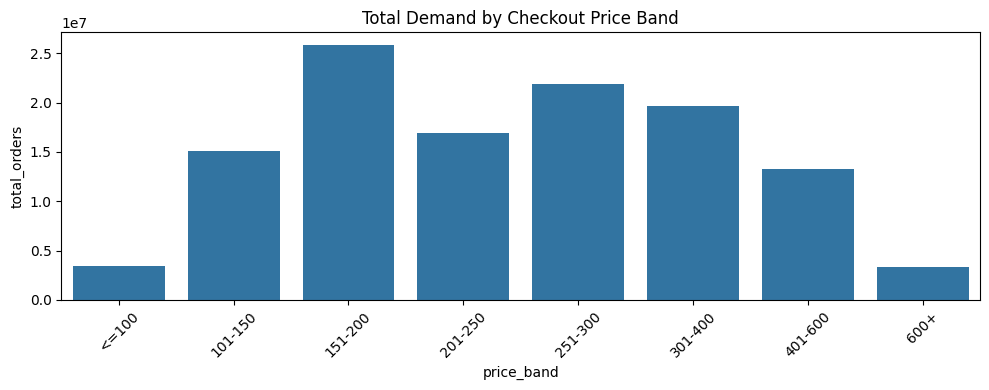

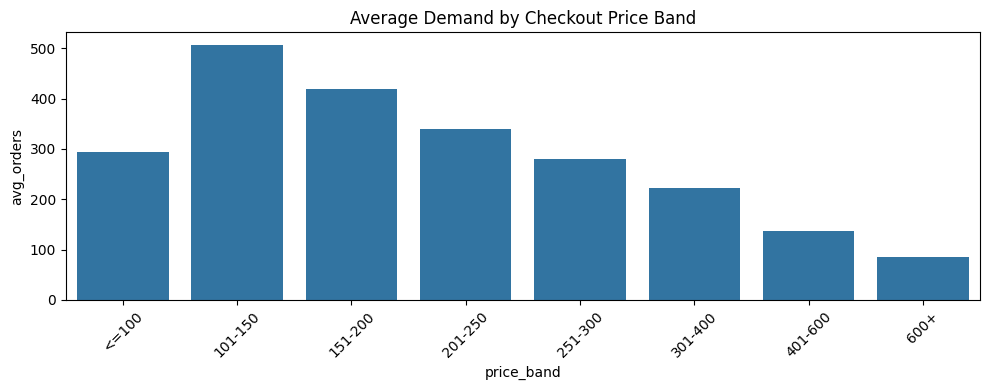

In [176]:
plt.figure(figsize=(10,4))
sns.barplot(data=price_summary, x="price_band", y="total_orders")
plt.title("Total Demand by Checkout Price Band")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(data=price_summary, x="price_band", y="avg_orders")
plt.title("Average Demand by Checkout Price Band")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
